# Bagging Ensemble

This notebook demonstrates bagging ensemble methods using the Iris dataset.

In [11]:
import pip
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
!pip install mlxtend
from mlxtend.plotting import plot_decision_regions

  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
INFO: pip is looking at multiple versions of mlxtend to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 524.3 kB/s eta 0:00:02
   --------------- ------------------------ 0.5/1.4 MB 524.3 kB/s eta 0:00:02
   ------------------------------- -------- 1.0/1.4 MB 824.4 kB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 996.5 kB/s eta 0:00:00


In [12]:
# Load the iris dataset
df = sns.load_dataset('iris')

# Display the first 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [13]:
# Encode species column
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

# Filter to binary classification (remove species 0)
df = df[df['species'] != 0][['sepal_width', 'petal_length', 'species']]

df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


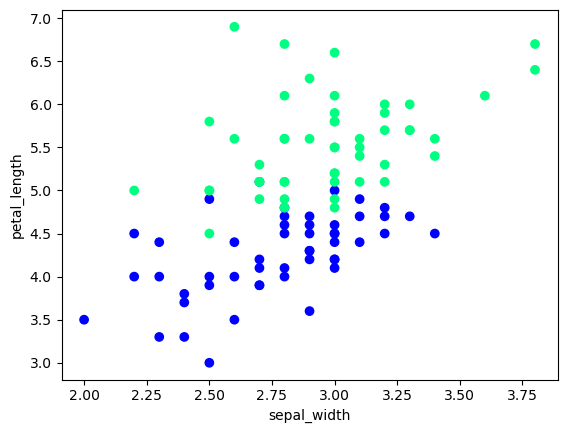

In [14]:
# Visualize the data
plt.scatter(df['sepal_width'], df['petal_length'], c=df['species'], cmap='winter')
plt.xlabel('sepal_width')
plt.ylabel('petal_length')
plt.show()

In [15]:
# Split the data
df = df.sample(100)

df_train = df.iloc[:60, :]
df_val = df.iloc[60:80, :]
df_test = df.iloc[80:, :]

x_test = df_test.drop(columns=['species'])
y_test = df_test['species']

print(f"Train: {df_train.shape}, Val: {df_val.shape}, Test: {df_test.shape}")

Train: (60, 3), Val: (20, 3), Test: (20, 3)


## Bagging with Decision Trees

In [16]:
# Helper function to evaluate models
def evaluate(model, X, y):
    model.fit(X, y)
    y_pred = model.predict(X)
    accuracy = accuracy_score(y, y_pred)
    print(f"Accuracy: {accuracy}")

    # Plot decision regions
    X_np = X.values
    y_np = y.values.astype(int)

    plt.figure(figsize=(8, 6))
    plot_decision_regions(X_np, y_np, clf=model, legend=2)
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.title('Decision Tree Decision Regions')
    plt.show()

Accuracy: 1.0


c:\Users\pawan\anaconda34\envs\dataAnalysisPython\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


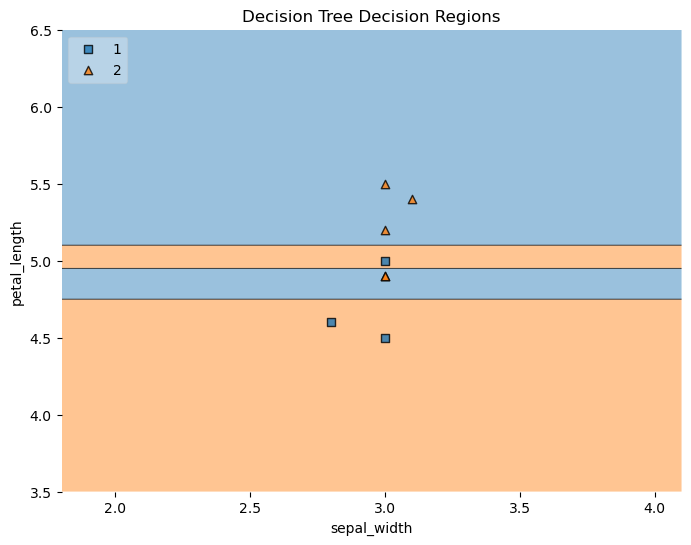

In [17]:
# Train first bagged model
df_bag = df_train.sample(8, replace=True)
x = df_bag.drop(columns=['species'])
y = df_bag['species']

dt_bag1 = DecisionTreeClassifier()
evaluate(dt_bag1, x, y)

Accuracy: 1.0


c:\Users\pawan\anaconda34\envs\dataAnalysisPython\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


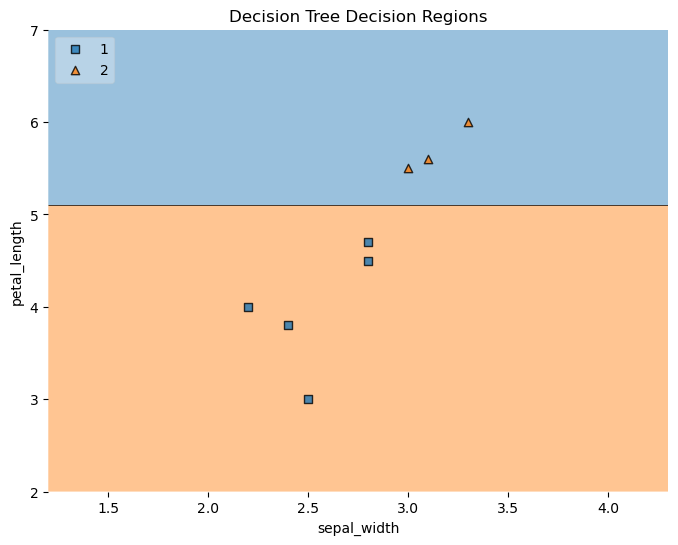

In [18]:
# Train second bagged model
df_bag = df_train.sample(8, replace=True)
x = df_bag.drop(columns=['species'])
y = df_bag['species']

dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2, x, y)

Accuracy: 1.0


c:\Users\pawan\anaconda34\envs\dataAnalysisPython\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


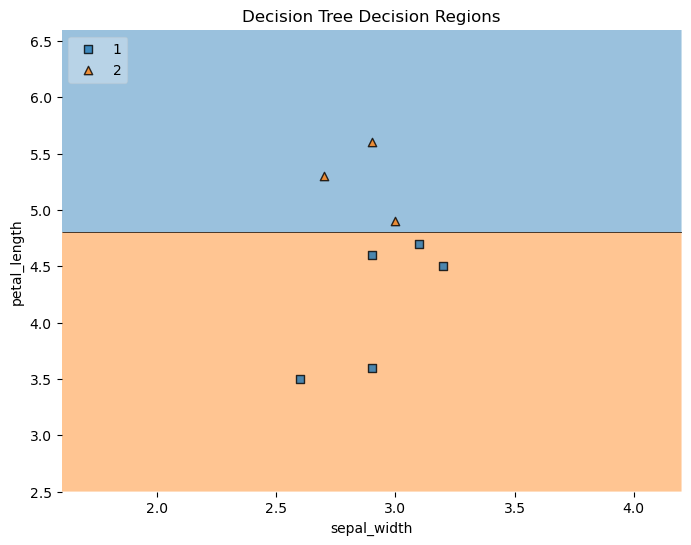

In [19]:
# Train third bagged model
df_bag = df_train.sample(8, replace=True)
x = df_bag.drop(columns=['species'])
y = df_bag['species']

dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3, x, y)

In [20]:
# Make predictions with all models
test_input = np.array([2.8, 5.1]).reshape(1, 2)

print('Predictor 1:', dt_bag1.predict(test_input))
print('Predictor 2:', dt_bag2.predict(test_input))
print('Predictor 3:', dt_bag3.predict(test_input))

Predictor 1: [1]
Predictor 2: [1]
Predictor 3: [2]


c:\Users\pawan\anaconda34\envs\dataAnalysisPython\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\pawan\anaconda34\envs\dataAnalysisPython\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\pawan\anaconda34\envs\dataAnalysisPython\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
